In [1]:
from pathlib import Path

import scarf

scarf.configure_output(level='WARNING', progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    'tenx_5K_pbmc_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)
ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
)

Downloading bucket files: 38209567 / 38209567 complete

Downloading bytes: 38209567 / 38209567 complete

In [2]:
gmt_path = Path('scarf_datasets/pbmc_signatures.gmt')
gmt_path.write_text(
    'T_cell\tna\tCD3D\tCD3E\tTRAC\tLTB\tIL7R\n'
    'B_cell\tna\tMS4A1\tCD79A\tCD37\tCD74\tHLA-DRA\n'
    'Myeloid\tna\tLST1\tS100A8\tS100A9\tCTSS\tFCER1G\n',
    encoding='utf-8',
)
gene_sets = scarf.read_gmt(gmt_path)
gene_sets

,source,target
0,T_cell,CD3D
1,T_cell,CD3E
2,T_cell,TRAC
3,T_cell,LTB
4,T_cell,IL7R
5,B_cell,MS4A1
6,B_cell,CD79A
7,B_cell,CD37
8,B_cell,CD74
9,B_cell,HLA-DRA


In [3]:
available = {str(name).upper() for name in ds.RNA.feats.fetch('names')}
(
    gene_sets.assign(
        matched=gene_sets['target'].str.upper().isin(available),
    )
    .groupby('source')['matched']
    .agg(['sum', 'count'])
)

,sum,count
source,,
B_cell,5,5
Myeloid,5,5
T_cell,5,5


In [4]:
weighted_sets = gene_sets.assign(weight=1.0)
weighted_sets.loc[
    weighted_sets['target'].isin(['S100A8', 'S100A9']),
    'weight',
] = 1.5

waggr = ds.run_waggr(
    weighted_sets,
    label='pbmc_waggr',
    mode='wmean',
    tmin=3,
    overwrite=True,
)
waggr.source_names, waggr.data.shape

Writing waggr enrichment: 1 / 1 complete

Scoring WAGGR: 2 / 2 complete

(array(['B_cell', 'Myeloid', 'T_cell'], dtype='<U7'), (3940, 3))

In [5]:
aucell = ds.run_aucell(
    gene_sets,
    label='pbmc_aucell',
    tmin=3,
    n_up=500,
    tie_seed=0,
    overwrite=True,
)
aucell.source_names, aucell.data.shape

Writing aucell enrichment: 1 / 1 complete

Scoring AUCell: 2 / 2 complete

(array(['B_cell', 'Myeloid', 'T_cell'], dtype='<U7'), (3940, 3))

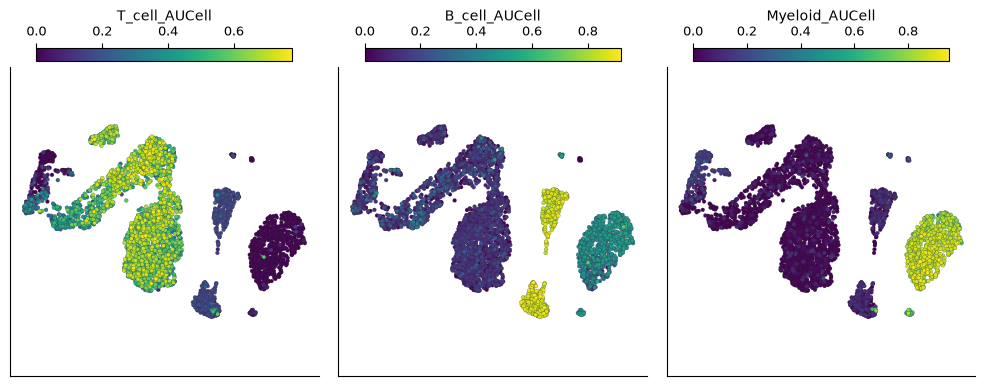

In [6]:
aucell_cols = []
for source in ['T_cell', 'B_cell', 'Myeloid']:
    result = ds.get_enrichment('pbmc_aucell', sources=[source])
    col = f'{source}_AUCell'
    ds.cells.insert(
        col,
        result.data.compute().ravel(),
        key=result.cell_key,
        overwrite=True,
    )
    aucell_cols.append(col)

present = [c for c in aucell_cols if c in ds.cells.columns]
if present:
    ds.plots.embedding(
        layout_key='RNA_UMAP',
        color_by=present,
        n_columns=3,
        sort_values=True,
    )

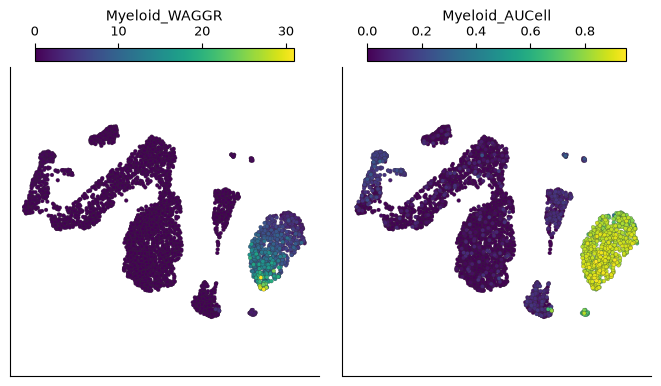

In [7]:
waggr_myeloid = ds.get_enrichment('pbmc_waggr', sources=['Myeloid'])
ds.cells.insert(
    'Myeloid_WAGGR',
    waggr_myeloid.data.compute().ravel(),
    key=waggr_myeloid.cell_key,
    overwrite=True,
)

compare = [
    c for c in ['Myeloid_WAGGR', 'Myeloid_AUCell'] if c in ds.cells.columns
]
if len(compare) == 2:
    ds.plots.embedding(
        layout_key='RNA_UMAP',
        color_by=compare,
        n_columns=2,
        sort_values=True,
    )